# III: Reduction and Background
# Notebook with some basic data reduction and analysis with python

## First, import necessary libraries

In [1]:
import numpy as np
import scipy
import matplotlib.pyplot as plt
from astropy.io import fits
import os

## Let's open fits files

In [2]:
dir = './m57' # directory where fits files are found
m57_files = []
#process all the directories in m57
for dirs in os.listdir(dir):
    print(dirs)
    for file in os.listdir(dir+'/'+dirs):
        if file.endswith(".fits"):
            m57_files.append((dir+'/'+dirs+'/'+file, dirs))
            
m57_science = []
for file, dirs in m57_files:
    image = fits.getdata(file)
    m57_science.append((image, dirs))

#multiple master flats for each filter

file2= './' + 'bias/' +'master_bias.fits' #file names
master_bias = fits.getdata(file2)  # data matrices
master_flats = []
for dirs in os.listdir('./flats'):
    file3 = './flats/' + dirs + '/master_flat_' + dirs + '.fits'  # file names
    master_flat = fits.getdata(file3)  # data matrices
    #make a name for each master flat
    master_flats.append((master_flat, dirs))


black
blue
green
red


## Reduce the science file

In [3]:
#we can delete because in the telescope we used there are not masks and so we can ignore this
m57_science_calibrated = []
for science, dirs in m57_science: 
  # Find the master flat matching the current dirs
  master_flat = next(flat for flat, name in master_flats if dirs in name)
  science_calibrated = (science - master_bias) / master_flat
  # This example needs a mask!
  # mask = np.zeros(np.shape(science_calibrated))
  # for i in range(len(science_calibrated)):
  #   for j in range(len(science_calibrated[i])):
  #     if master_flat[i][j] < 0.2:
  #       science_calibrated[i][j] = 0
  #       mask[i][j] = 1
  # mask = mask.astype(bool)
  m57_science_calibrated.append((science_calibrated, dirs))


## Plot fits files

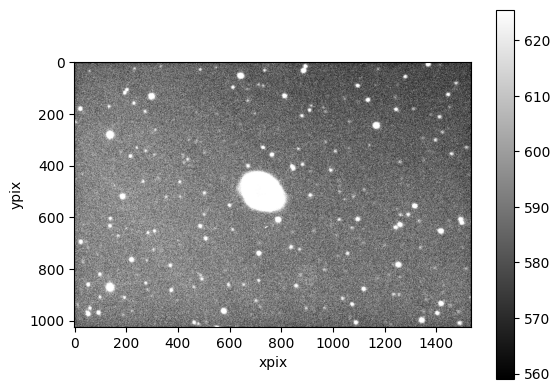

In [4]:
#one plot to try to see the first one only
for science_calibrated, dirs in m57_science_calibrated:
    lo,up = np.percentile(science_calibrated,5),np.percentile(science_calibrated,95)
    plt.figure()
    plt.imshow(science_calibrated,cmap='gray',clim=(lo,up))
    plt.colorbar()
    plt.xlabel('xpix')
    plt.ylabel('ypix')
    break
    

## Get background and background noise

In [7]:
!pip install photutils #only needed if its being run on colabs

ERROR: Invalid requirement: '#only': Expected package name at the start of dependency specifier
    #only
    ^


In [5]:
from photutils.background import Background2D, MedianBackground
from astropy.stats import SigmaClip
sigma_clip = SigmaClip(sigma=3.0)
bkg_estimator = MedianBackground()
bkg_list = []
for science_calibrated, dirs in m57_science_calibrated:
      bkg = Background2D(science_calibrated,(50,50),filter_size=(3,3),sigma_clip=sigma_clip, bkg_estimator=bkg_estimator)
      print("      Median background found: %f, median bkg noise: %f"
            %(bkg.background_median,bkg.background_rms_median)  )
      bkg_list.append(bkg)


c:\Users\saraj\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


      Median background found: 589.834570, median bkg noise: 17.748037
      Median background found: 499.127528, median bkg noise: 16.583216
      Median background found: 486.649414, median bkg noise: 16.561294
      Median background found: 483.894603, median bkg noise: 16.487718
      Median background found: 480.512303, median bkg noise: 16.428272
      Median background found: 482.005626, median bkg noise: 16.443119
      Median background found: 474.857558, median bkg noise: 16.345217
      Median background found: 472.927537, median bkg noise: 16.346285
      Median background found: 470.354064, median bkg noise: 16.260131
      Median background found: 465.539485, median bkg noise: 16.199573
      Median background found: 69.152964, median bkg noise: 8.393989
      Median background found: 60.925724, median bkg noise: 8.360258
      Median background found: 59.838996, median bkg noise: 8.315473
      Median background found: 59.316650, median bkg noise: 8.275367
      Median b

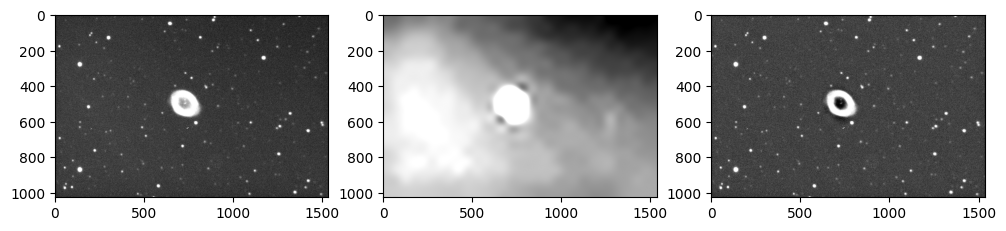

In [9]:
for idx, (science_calibrated, dirs) in enumerate(m57_science_calibrated):
    bkg = bkg_list[idx]
    fig,ax = plt.subplots(1,3,figsize=(12,6))
    lo,up = np.percentile(science_calibrated,1),np.percentile(science_calibrated,99)
    ax[0].imshow(science_calibrated,cmap='gray',clim=(lo,up))
    lo,up = np.percentile(bkg.background,1),np.percentile(bkg.background,95)
    ax[1].imshow(bkg.background,cmap='gray',clim=(lo,up))
    lo,up = np.percentile(science_calibrated-bkg.background,1),np.percentile(science_calibrated-bkg.background,99)
    ax[2].imshow(science_calibrated-bkg.background,cmap='gray',clim=(lo,up))



    break

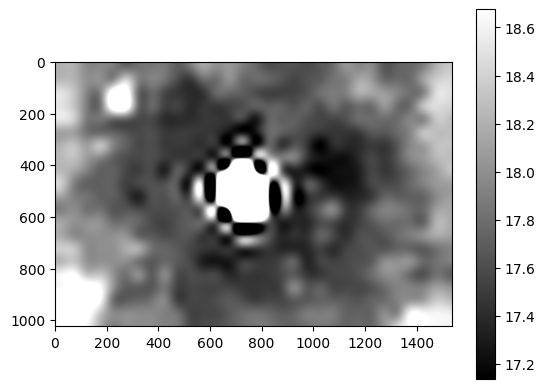

In [12]:
for idx, (science_calibrated, dirs) in enumerate(m57_science_calibrated):
    bkg = bkg_list[idx]    
    lo,up = np.percentile(bkg.background_rms,1),np.percentile(bkg.background_rms,95)
    plt.imshow(bkg.background_rms,cmap='gray',clim=(lo,up))
    plt.colorbar()
    break